In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.filters.bk_filter import bkfilter
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose

In [78]:
api_key = '87286775ed088aa20d3a56597d9840ae'

# Initialize FRED API
fred = Fred(api_key= api_key)

# Seasonally adjusted GDP
gdpc1 = fred.get_series('GDPC1')
gdp = pd.DataFrame(gdpc1, columns = ['gdp_adjusted'])

# Population
pop = fred.get_series('CNP16OV')
pop = pd.DataFrame(pop, columns = ['pop'])

# Seasonally adjusted gdp per capita, where the multiplication by 1000000 is for interpretation as dollar amounts
df = pd.merge(gdp, pop, left_index = True, right_index = True)
df['log_gdp_per_capita'] = np.log(df['gdp_adjusted']/df['pop'])*1000000

In [79]:
# 1(a)
# Log-linear trend
time = np.arange(len(df))
coeffs = np.polyfit(time, df['log_gdp_per_capita'], 1) # the 1 makes the fit linear
trend_linear = np.polyval(coeffs, time)
df['detrended_linear'] = df['log_gdp_per_capita'] - trend_linear

# Hodrick-Prescott filter
cycle_hp, trend_hp = hpfilter(df['log_gdp_per_capita'], lamb = 1600)
df['detrended_hp'] = cycle_hp

# Baxter-King band-pass filter. We'll get 12 missing values at the starting and ending of the series
# due to the K = 12 lead-lag length chosen. We allow for 6-32 quarters of oscillation.
df['detrended_bk'] = bkfilter(df['log_gdp_per_capita'], low = 6, high = 32, K = 12) 

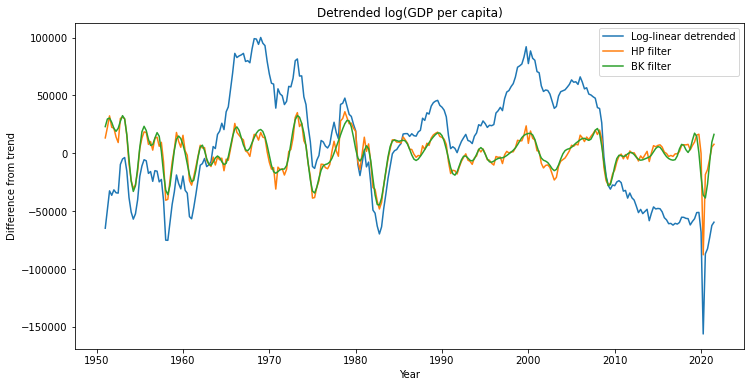

In [80]:
# 1(b)
df = df.dropna(subset = ['detrended_bk']) # Only plotting the common values available
plt.figure(figsize = (12, 6))
plt.plot(df.index, df['detrended_linear'], label = 'Log-linear detrended')
plt.plot(df.index, df['detrended_hp'], label = 'HP filter')
plt.plot(df.index, df['detrended_bk'], label = 'BK filter')
plt.title('Detrended log(GDP per capita)')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Difference from trend')
plt.savefig('1b.png')
plt.show()

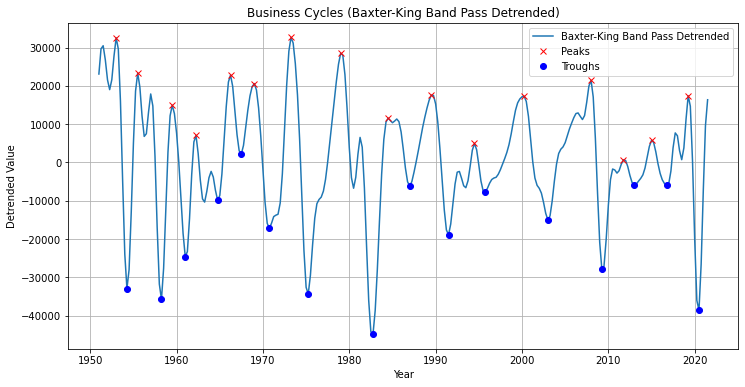

In [81]:
# 1(c)
# Find peaks and troughs
peaks, _ = find_peaks(df['detrended_bk'], distance = 10)  # Minimum 2.5 years between peaks
troughs, _ = find_peaks(-df['detrended_bk'], distance = 10)

# Create the plot
plt.figure(figsize = (12, 6))
plt.plot(df.index, df['detrended_bk'], label = 'Baxter-King Band Pass Detrended')
plt.plot(df.index[peaks], df['detrended_bk'].iloc[peaks], 'x', color = 'red', label = 'Peaks')
plt.plot(df.index[troughs], df['detrended_bk'].iloc[troughs], 'o', color = 'blue', label = 'Troughs')

# Customize the plot
plt.title('Business Cycles (Baxter-King Band Pass Detrended)')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Detrended Value')
plt.grid(True)

plt.savefig('1c.png')
plt.show()

In [82]:
# 1(c)
# LOOK AT THIS AGAIN
expansions = df.index[peaks[1:]] - df.index[troughs[:-1]]  
recessions = df.index[troughs] - df.index[peaks] 

expansion_durations = expansions.mean().days
recession_durations = recessions.mean().days

# Converting quarterly to yearly data
expansion_durations_years = expansion_durations / 365.5
recession_durations_years = recession_durations / 365.5

print(f'Average expansion duration: {expansion_durations_years} years')
print(f'Average recession duration: {recession_durations_years} years')

Average expansion duration: 2.4459644322845415 years
Average recession duration: 1.920656634746922 years


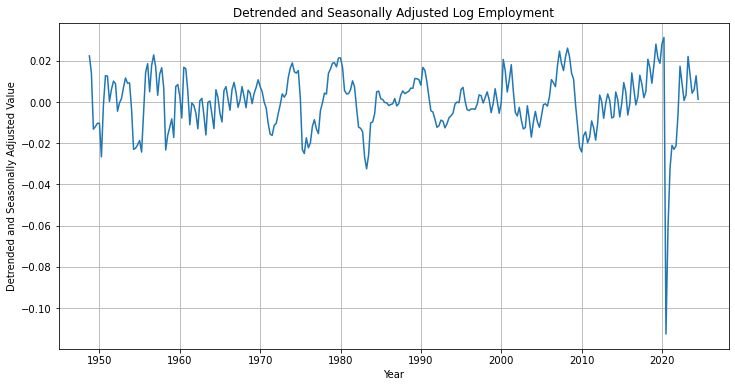

In [83]:
# 2
employment = fred.get_series('LNU02000000')
employment = employment.resample('Q').mean()
employment = pd.DataFrame(employment, columns = ['emp'])

employment['log_emp'] = np.log(employment['emp'])

# Detrend using Hodrick-Prescott filter
cycle, trend = hpfilter(employment['log_emp'], lamb = 1600)

# Performing seasonal decomposition
decomposition = seasonal_decompose(cycle, model='additive', period=4)

# The detrended and seasonally adjusted series
detrended_seasonally_adjusted = decomposition.trend + decomposition.resid

# Plot the result
plt.figure(figsize=(12, 6))
plt.plot(detrended_seasonally_adjusted)
plt.title('Detrended and Seasonally Adjusted Log Employment')
plt.xlabel('Year')
plt.ylabel('Detrended and Seasonally Adjusted Value')
plt.grid(True)
plt.savefig('2.png')
plt.show()

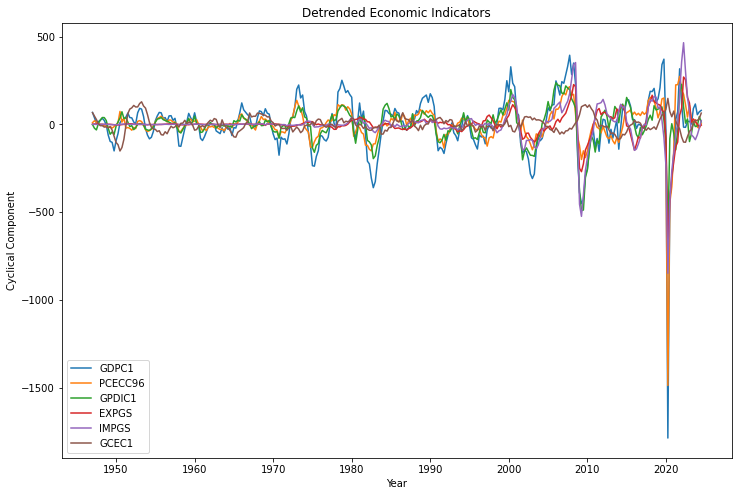

In [84]:
# 3(a)
series_codes = ['GDPC1', 'PCECC96', 'GPDIC1', 'EXPGS', 'IMPGS', 'GCEC1']
data = pd.DataFrame()

for code in series_codes:
    series = fred.get_series(code)
    data[code] = series

# Ensure all series have the same start date
data = data.dropna()

# (a) Detrend the series using Hodrick-Prescott filter
detrended_data = pd.DataFrame()

for column in data.columns:
    cycle, trend = hpfilter(data[column], lamb = 1600)
    detrended_data[column] = cycle

# Plot the detrended series
plt.figure(figsize=(12, 8))
for column in detrended_data.columns:
    plt.plot(detrended_data.index, detrended_data[column], label=column)
plt.legend()
plt.title('Detrended Economic Indicators')
plt.xlabel('Year')
plt.ylabel('Cyclical Component')
plt.savefig('3a.png')
plt.show()

In [92]:
# 3(b)

# Variance-covariance matrix
cov_matrix = detrended_data.cov()

# Find most and least volatile series
volatilities = detrended_data.std()
most_volatile = volatilities.idxmax()
least_volatile = volatilities.idxmin()

In [94]:
least_volatile

'GCEC1'

In [86]:
# 3(c) 
# Compute correlations with GDP
correlations = detrended_data.corr()['GDPC1'].sort_values(ascending = False)

In [88]:
correlations

GDPC1      1.000000
PCECC96    0.893113
GPDIC1     0.845978
IMPGS      0.692189
EXPGS      0.681485
GCEC1     -0.241072
Name: GDPC1, dtype: float64

In [89]:
# 4(a)

series_codes = ['AWHMAN', 'CE16OV', 'UNRATE', 'GDPC1']
data = pd.DataFrame()

for code in series_codes:
    series = fred.get_series(code)
    data[code] = series

# Ensure all series have the same start date
data = data.dropna()

# Detrend Employment (CE16OV)
cycle, trend = hpfilter(data['CE16OV'], lamb = 1600)
data['CE16OV_detrended'] = cycle

# Convert all series to quarterly
data_quarterly = data.resample('Q').mean()

In [90]:
# 4(b)
# Compute covariances with GDP
gdp = data_quarterly['GDPC1']
labor_series = ['AWHMAN', 'CE16OV_detrended', 'UNRATE']

# Contemporaneous covariances
covariances = {series: np.cov(gdp, data_quarterly[series])[0, 1] for series in labor_series}
print("Contemporaneous covariances with GDP:")
for series, cov in covariances.items():
    print(f"{series}: {cov}")


Contemporaneous covariances with GDP:
AWHMAN: 2611.4114743778077
CE16OV_detrended: 318990.0053677846
UNRATE: 716.1662564454665


In [91]:
# 4(c)
# Compute lead and lag covariances
lead_covariances = {}
lag_covariances = {}

for series in labor_series:
    lead_covariances[series] = np.cov(gdp[1:], data_quarterly[series][:-1])[0, 1]
    lag_covariances[series] = np.cov(gdp[:-1], data_quarterly[series][1:])[0, 1]

print("\nLead covariances with GDP:")
for series, cov in lead_covariances.items():
    print(f"{series}: {cov}")

print("\nLag covariances with GDP:")
for series, cov in lag_covariances.items():
    print(f"{series}: {cov}")


Lead covariances with GDP:
AWHMAN: 2620.6894399807147
CE16OV_detrended: 177648.96761584675
UNRATE: 850.116634136934

Lag covariances with GDP:
AWHMAN: 2577.1051472495456
CE16OV_detrended: 282220.4890923815
UNRATE: 687.9477130783253
